# **Introduction to Calculus for Machine Learning**

![rainbow](https://raw.githubusercontent.com/ancilcleetus/AI-Learning-Lab/main/assets/rainbow-divider.png)

# 📖 TABLE OF CONTENTS

- [Setup](#Setup)
- [Understanding Functions](#Understanding-Functions)
  - [What is a Function?](#What-is-a-Function?)
  - [Functions Examples](#Functions-Examples)
  - [Defining a Function in Python](#Defining-a-Function-in-Python)
  - [Evaluating a Function](#Evaluating-a-Function)
  - [Plotting the Function](#Plotting-the-Function)
  - [Understanding the Code for Plotting](#Understanding-the-Code-for-Plotting)
  - [Evaluating Function with the Plot](#Evaluating-Function-with-the-Plot)
  - [Common Mathematical Functions](#Common-Mathematical-Functions)
  - [Lesson Summary](#Lesson-Summary)
- [References](#References)

![rainbow](https://raw.githubusercontent.com/ancilcleetus/AI-Learning-Lab/main/assets/rainbow-divider.png)

# Setup

Before we jump in, let's quickly run the setup cell. It checks the environment (GPU, library versions) and sets random seeds for reproducibility — we want identical results on every run.

In [ ]:
# 🔧 Setup: Run this cell first!
# Environment check + random seeds for reproducibility

import sys
import time
import random
import numpy as np
import pandas as pd
import matplotlib as mpl
import torch
import torch.nn as nn

print(f"📦 Python       {sys.version.split()[0]}")
print(f"🔢 NumPy        {np.__version__}")
print(f"🐼 Pandas       {pd.__version__}")
print(f"📊 Matplotlib   {mpl.__version__}")
print(f"🔥 PyTorch      {torch.__version__}")

# GPU check (only needed for optional deep-feature experiments)
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"✅ GPU available: {torch.cuda.get_device_name(0)}")
    print(f"   Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    device = torch.device("cpu")
    print("⚠️ No GPU detected")

DEVICE_LABEL = "GPU" if device.type == "cuda" else "CPU"

# Random seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"\n🎲 Random seed set to {SEED} (Python, NumPy, PyTorch)")

%matplotlib inline
%config InlineBackend.figure_format = 'jpeg'   # photos as JPEG, not PNG — ~10× smaller notebook
# Remove character limits for all columns of Pandas dataframes permanently in this session
pd.set_option('display.max_colwidth', None)

📦 Python       3.13.15
🔢 NumPy        2.1.3
🐼 Pandas       2.2.3
📊 Matplotlib   3.10.0
🔥 PyTorch      2.11.0+cpu
⚠️ No GPU detected

🎲 Random seed set to 42 (Python, NumPy, PyTorch)


![rainbow](https://raw.githubusercontent.com/ancilcleetus/AI-Learning-Lab/main/assets/rainbow-divider.png)

# Understanding Functions

Today, we're talking about **functions**. By the end, you'll know what functions are in math and how they apply to machine learning. We'll also teach you how to define and use functions in Python. Let's begin!

## What is a Function?

A function in math relates an input to an output. It's like a machine: you put something in, and it gives you something back. For instance, if a function adds 2 to any number you give it, putting in 3 gives you 5, and putting in 7 gives you 9.

Formally, if $x$ is our input and $f$ is our function, our output is $f(x)$, written as $f: x \mapsto f(x)$.

## Functions Examples

Here are some common examples of functions in math:

1. **Linear Function**: $f(x) = 2x + 3$
2. **Quadratic Function**: $f(x) = x^2 -4x + 4$
3. **Exponential Function**: $f(x) = e^x$
4. **Logarithmic Function**: $f(x) = \log (x)$

## Defining a Function in Python

Let's define a quadratic function in Python. We'll use the example function $f(x) = x^2 + 2x + 1$.

In [ ]:
# Defining a simple function
def simple_function(x):
    return x**2 + 2*x + 1

Here, `simple_function` is the name, and `x` is the input. The function returns the value of $x^2 + 2x + 1$.

Here's the breakdown:
* `def` is the keyword to define a function.
* `simple_function(x)` is the name and parameter.
* `return x**2 + 2*x + 1` is what the function does.

Quadratic functions are common in machine learning for optimization problems. For example, finding the best-fit line for data points involves solving a quadratic problem.

## Evaluating a Function

We can find our function's value at different $x$. For $x=3$, what does `simple_function` return? Let's see:

In [ ]:
# Evaluate function at x=3
result = simple_function(3)
print(f'f(3) = {result}')

f(3) = 16


When you call `simple_function(3)`, Python:
1. Takes $x=3$ as the input.
2. Computes $3^2 + 2 \times 3 + 1$.
3. Returns 16, which is printed as `f(3) = 16`.

## Plotting the Function

If we evaluate the function at every possible $x$, we will get a list of corresponding function values. Each pair $x$ and $f(x)$ can be represented as a point on the $XY$ plane. If we draw all such pairs, we will get the **plot** of our function.

Plotting in python is easy with the `matplotlib` library:

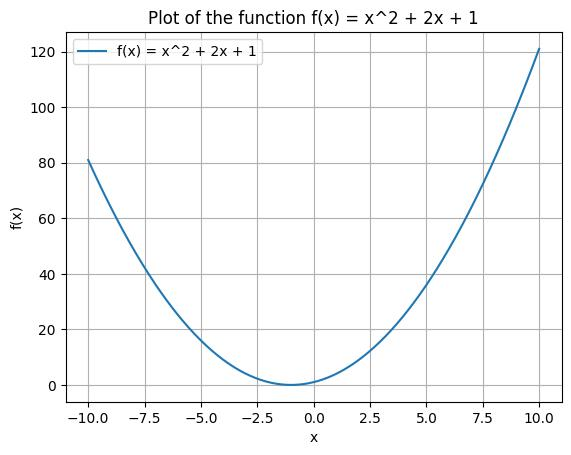

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Define the function again for plotting
def simple_function(x):
    return x**2 + 2*x + 1

# Generate x values
x = np.linspace(-10, 10, 400)
# Generate y values using the function
y = simple_function(x)

# Plot the function
plt.plot(x, y, label='f(x) = x^2 + 2x + 1')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Plot of the function f(x) = x^2 + 2x + 1')
plt.legend()
plt.grid(True)
plt.show()

The above code produced a plot of the quadratic function $f(x) = x^2 + 2x + 1$. The curve will help you better understand how the function behaves.

Here are some insights we can get by simply looking at this picture:
* The function is zero at around $x = -1$.
* Before this, the function decreases.
* After this, the function increases.
* The farther we from the $x=-1$, the faster this function grows.

## Understanding the Code for Plotting

To help you better understand plotting, here is a breakdown of the code:
* We import `matplotlib.pyplot` for plotting and `numpy` for array handling.
* We define the function `simple_function` as before.
* We generate a list of x-values ranging from -10 to 10 using `np.linspace(-10, 10, 400)`. The `400` specifies the number of points to generate, ensuring a smooth plot.
* We compute the corresponding y-values by passing our list of x-values to `simple_function`. Although the function is designed for a single input number, numpy allows it to process the entire list of x-values, returning a list of y-values.
* We plot these x and y values using `plt.plot`.

## Evaluating Function with the Plot

Once you have the function's plot, you can see the general rule this function represents. Also, the plot can be used to evaluate the function's value at a specific point.

## Common Mathematical Functions

Mathematical functions play a crucial role in various fields, including machine learning. Here are some common mathematical functions and how to calculate them in Python.

**Trigonometric Functions**:
1. **Sine**: $\sin (x)$. Python: `math.sin(x)`
2. **Cosine**: $\cos (x)$. Python: `math.cos(x)`
3. **Tangent**: $\tan (x)$. Python: `math.tan(x)`

**Logarithms**:
1. **Natural Logarithm**: $\log (x)$ (base $e$). Python: `math.log(x)`
2. **Logarithm Base 10**: $\log_{10} (x)$. Python: `math.log10(x)`

**Other**:
1. **Square Root**: $\sqrt{x}$. Python: `math.sqrt(x)`
2. **Exponential**: $e^x$. Python: `math.exp(x)`

## Lesson Summary

Today, we learned what functions are and how they relate inputs to outputs in math and programming. We also learned how to define a function in Python, saw a practical example of evaluating a function, and even plotted a function.

Functions are essential in machine learning for modeling and solving optimization problems. Understanding functions lays the foundation for more complex topics.

![rainbow](https://raw.githubusercontent.com/ancilcleetus/AI-Learning-Lab/main/assets/rainbow-divider.png)

# References

- **[CodeSignal: Introduction to Calculus for Machine Learning Course](https://codesignal.com/learn/courses/introduction-to-calculus-for-machine-learning)**

![rainbow](https://raw.githubusercontent.com/ancilcleetus/AI-Learning-Lab/main/assets/rainbow-divider.png)